# Preparation of the data

In [1]:
import pandas as pd
dka_patients = pd.read_csv('icu_dka_dataset.csv')

In [2]:
# Prepare data
X = dka_patients.drop(['in_hospital_death', 'subject_id'], axis=1)  # Exclude outcome and ID
y = dka_patients['in_hospital_death']

In [3]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded = X_encoded.dropna()
X_encoded = X_encoded.astype(float)
y_aligned = y.loc[X_encoded.index]

In [4]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1028 entries, 0 to 1570
Columns: 102 entries, age to insurance_Private
dtypes: float64(102)
memory usage: 827.2 KB


In [1]:
import statsmodels.api as sm
import itertools
import numpy as np
# from sklearn.model_selection import train_test_split


In [38]:
non_numeric = X.select_dtypes(include='object').columns
print(non_numeric)

Index(['race', 'gender', 'insurance'], dtype='object')


In [36]:
# Verifica tipos de datos
print(X_encoded)


      age  weight        los  aki  ckd  diabetes_with_cc  diabetes_without_cc  \
0      50   144.0   0.869907    0    0                 0                    1   
1      60    98.4   2.238762    1    1                 0                    1   
2      60    94.6   3.085972    1    0                 0                    1   
4      24    55.0   1.848657    1    0                 0                    1   
5      91    47.3   0.717766    1    0                 0                    1   
...   ...     ...        ...  ...  ...               ...                  ...   
1566   38   102.6  19.012002    1    1                 0                    0   
1567   91   103.6   1.373252    1    0                 1                    1   
1568   62   110.0   2.260579    1    0                 0                    1   
1569   63    80.1   0.935914    1    0                 1                    1   
1570   48    67.9   1.790995    0    0                 0                    1   

      cardiac_disease  hype

In [42]:
def bic_subset_selection(X, y):
    X = sm.add_constant(X)  # Adds intercept term
    n, k = X.shape
    best_bic = float('inf')
    best_model = None
    best_features = None

    for k in range(1, X.shape[1]):  # try subsets of all sizes
        for subset in itertools.combinations(X.columns[1:], k):  # skip the intercept
            X_subset = X[list(subset)]
            X_subset = sm.add_constant(X_subset)
            model = sm.OLS(y, X_subset).fit()
            bic = model.bic
            if bic < best_bic:
                best_bic = bic
                best_model = model
                best_features = subset

    print("Best BIC:", best_bic)
    print("Best subset of features:", best_features)
    return best_model

In [43]:
print(X_encoded.dtypes)           # Should all be int or float
print(np.asarray(X_encoded)) 

age                     float64
weight                  float64
los                     float64
aki                     float64
ckd                     float64
                         ...   
race_WHITE - RUSSIAN    float64
gender_M                float64
insurance_Medicare      float64
insurance_Other         float64
insurance_Private       float64
Length: 102, dtype: object
[[ 50.         144.           0.86990741 ...   0.           0.
    1.        ]
 [ 60.          98.4          2.23876157 ...   0.           0.
    1.        ]
 [ 60.          94.6          3.08597222 ...   1.           0.
    0.        ]
 ...
 [ 62.         110.           2.2605787  ...   0.           0.
    0.        ]
 [ 63.          80.1          0.93591435 ...   1.           0.
    0.        ]
 [ 48.          67.9          1.79099537 ...   0.           0.
    0.        ]]


In [44]:
model = bic_subset_selection(X_encoded, y_aligned)
print(model.summary())


MissingDataError: exog contains inf or nans

# XGBoost Model

In [4]:
pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 162.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 169.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split( X_encoded, y_aligned, test_size=0.3, random_state=42, stratify=y_aligned)

In [7]:
print(len(X_train))
print(len(X_test))

719
309


### Normalice

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score

In [79]:
def normalise_data(train, test):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train)  
    test_scaled = scaler.transform(test)
    return train_scaled, test_scaled

In [90]:
def get_scale_pos_weight(y_train):
    # Calculate scale_pos_weight for class imbalance
    n_negative = sum(y_train == 0)
    n_positive = sum(y_train == 1)
    scale_pos_weight = n_negative / n_positive if n_positive > 0 else 1

In [92]:
def train_xgboost(X_train_scaled, y_train): 
    scale_pos_weight = get_scale_pos_weight(y_train)
    # Train XGBoost classifier
    model_xgb = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eta=0.1,
        gamma=0.25,
        colsample_bytree=1,
        min_child_weight=1,
        subsample=0.5,
        # scale_pos_weight=scale_pos_weight,
        eval_metric='logloss')
    model_xgb.fit(X_train_scaled, y_train)
    return model_xgb


In [93]:
X_train_scaled, X_test_scaled = normalise_data(X_train, X_test)

In [95]:
model_xgb = train_xgboost(X_train_scaled, y_train)

In [96]:
model_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eta=0.1, eval_metric='logloss', feature_types=None,
              feature_weights=None, gamma=0.25, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [97]:
# Evaluate model 
y_pred = model_xgb.predict(X_test_scaled)
y_pred_proba = model_xgb.predict_proba(X_test_scaled)[:, 1]

In [98]:
accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.2f}")
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"AUC: {auc:.2f}")

Accuracy: 0.94
Sensitivity: 0.47
Specificity: 0.98
AUC: 0.96


In [85]:
threshold = 0.2  
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
sensitivity_adj = recall_score(y_test, y_pred_adjusted)
tn_adj, fp_adj, fn_adj, tp_adj = confusion_matrix(y_test, y_pred_adjusted).ravel()
specificity_adj = tn_adj / (tn_adj + fp_adj) if (tn_adj + fp_adj) > 0 else 0
print(f"\nWith threshold {threshold}:")
print(f"Sensitivity: {sensitivity_adj:.2f}")
print(f"Specificity: {specificity_adj:.2f}")


With threshold 0.2:
Sensitivity: 0.63
Specificity: 0.95


In [86]:
# Get feature importance
importances = model_xgb.feature_importances_
features = X_encoded.columns

In [87]:
# Create a DataFrame for importance
feat_imp_df = pd.DataFrame({'feature': features, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)
print(feat_imp_df.head(20))  # Top 20 features

               feature  importance
62                sofa    0.113977
27         lactate_max    0.059722
61              apsiii    0.051414
99  insurance_Medicare    0.039688
2                  los    0.026098
5     diabetes_with_cc    0.025801
0                  age    0.022478
60         urineoutput    0.021835
40    chloride_initial    0.021066
54     bicarbonate_max    0.020055
24             wbc_max    0.019161
32       potassium_min    0.018628
44             bun_min    0.017915
20      hemoglobin_min    0.017796
42        chloride_max    0.017576
33       potassium_max    0.017494
15         calcium_max    0.017049
14         calcium_min    0.015026
45             bun_max    0.014725
23             wbc_min    0.014699


"weight": number of times a feature appears in trees

"gain": average gain from splits using the feature (often most informative)

"cover": number of observations related to splits

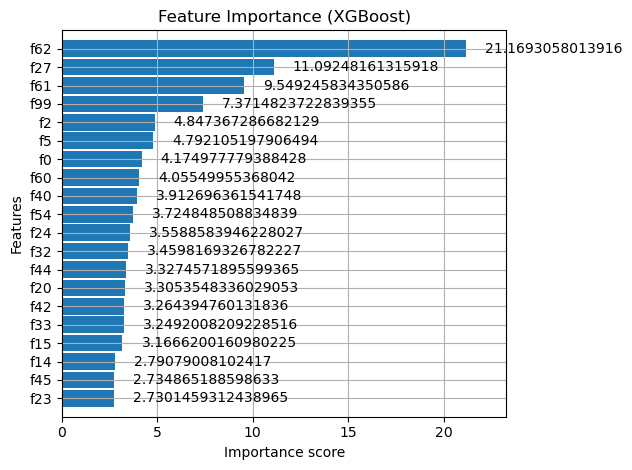

In [88]:
xgb.plot_importance(model_xgb, max_num_features=20, importance_type='gain', height=0.9)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()


In [18]:
import matplotlib.pyplot as plt

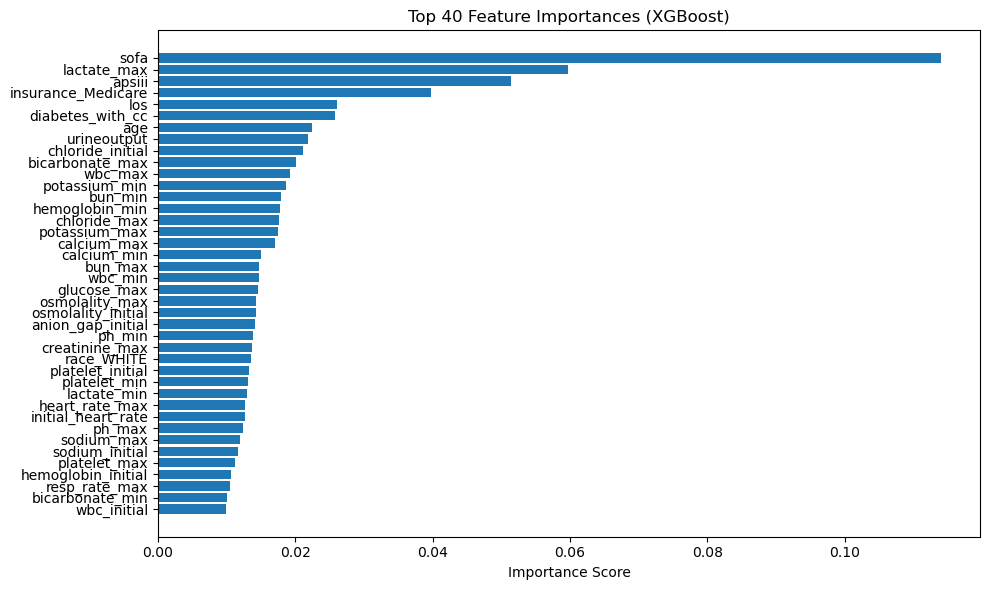

In [45]:
top_n = 40
top_feats = feat_imp_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_feats['feature'][::-1], top_feats['importance'][::-1])
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

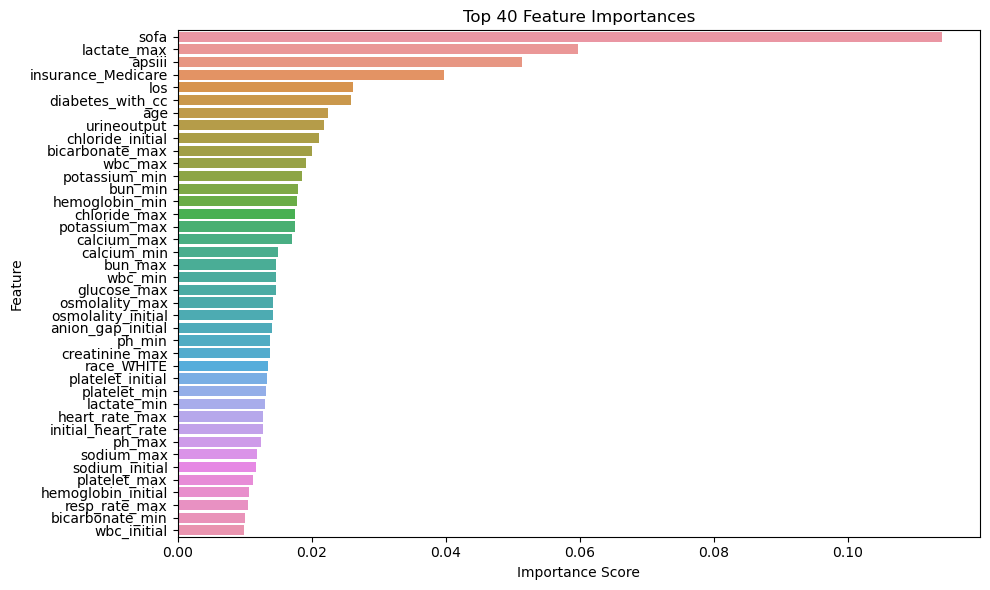

In [44]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=top_feats)
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# SHAP

In [74]:
top_40_features = feat_imp_df['feature'].head(40).tolist()
print("\nTop 40 Features Selected:")
print(top_40_features)


Top 40 Features Selected:
['sofa', 'lactate_max', 'apsiii', 'insurance_Medicare', 'los', 'diabetes_with_cc', 'age', 'urineoutput', 'chloride_initial', 'bicarbonate_max', 'wbc_max', 'potassium_min', 'bun_min', 'hemoglobin_min', 'chloride_max', 'potassium_max', 'calcium_max', 'calcium_min', 'bun_max', 'wbc_min', 'glucose_max', 'osmolality_max', 'osmolality_initial', 'anion_gap_initial', 'ph_min', 'creatinine_max', 'race_WHITE', 'platelet_initial', 'platelet_min', 'lactate_min', 'heart_rate_max', 'initial_heart_rate', 'ph_max', 'sodium_max', 'sodium_initial', 'platelet_max', 'hemoglobin_initial', 'resp_rate_max', 'bicarbonate_min', 'wbc_initial']


In [66]:
X_train_top40 = X_train[top_40_features]
X_test_top40 = X_test[top_40_features]

In [57]:
import numpy as np
import shap

In [54]:
# Explain model
explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_train)

In [58]:
np.shape(shap_values.values)

(719, 102)

## Waterfall plot

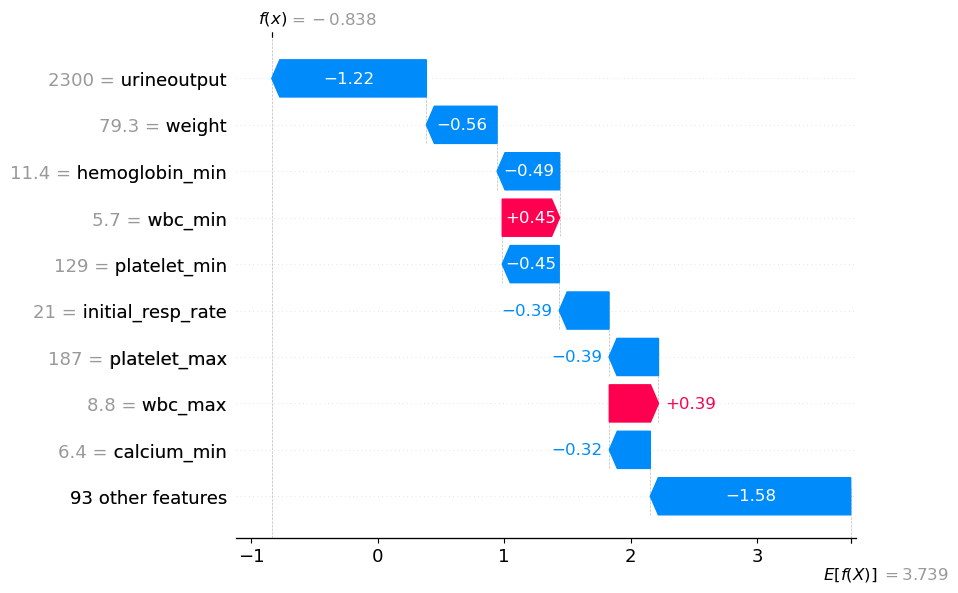

In [59]:
# for the 1st observation
shap.plots.waterfall(shap_values[0])

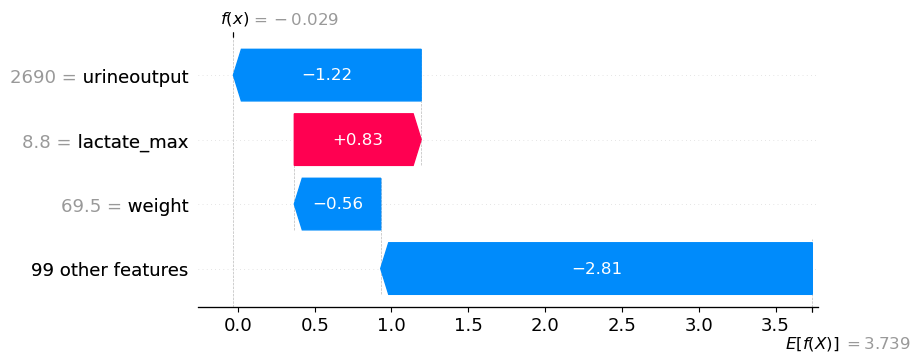

In [60]:
shap.plots.waterfall(shap_values[1], max_display=4)

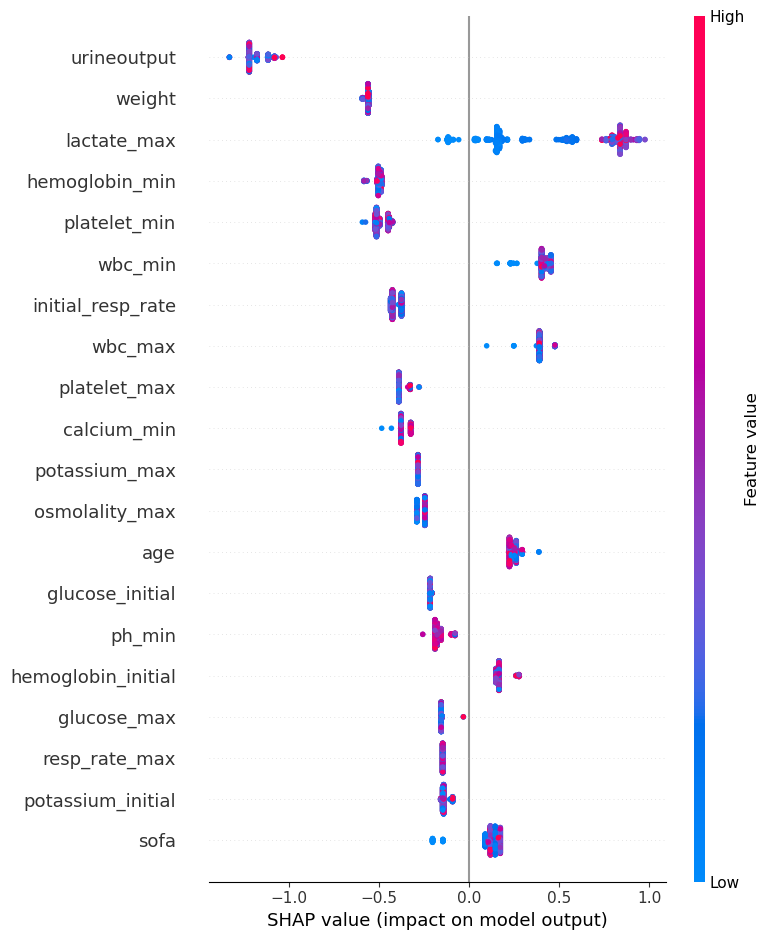

In [61]:
shap.summary_plot(shap_values, X_train, plot_type="dot")

In [86]:
## Force plot

In [89]:
shap.plots.force(shap_values[0])
shap.plots.force(shap_values[0:100]) 

## Absolute Mean SHAP
Which features are more important to the model.

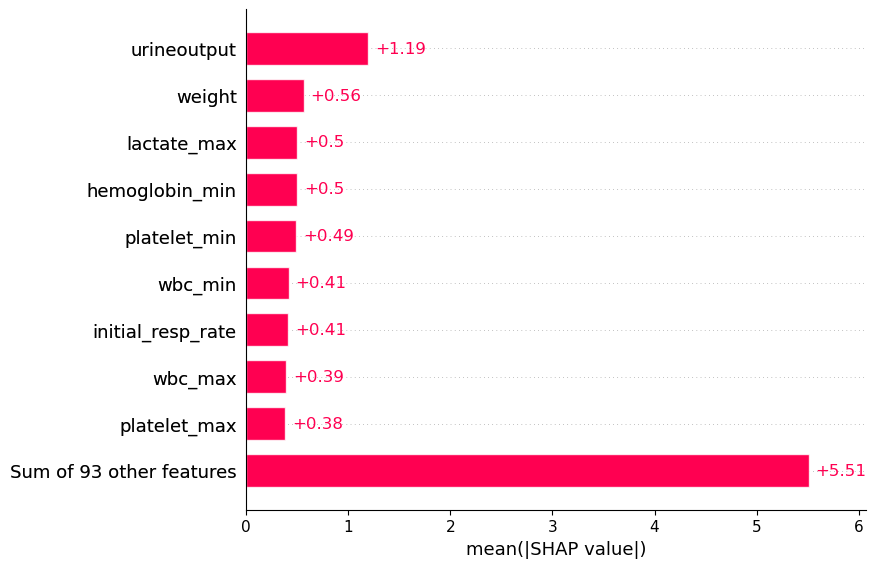

In [62]:
shap.plots.bar(shap_values)

## Beeswarm plot
All of the shap values.

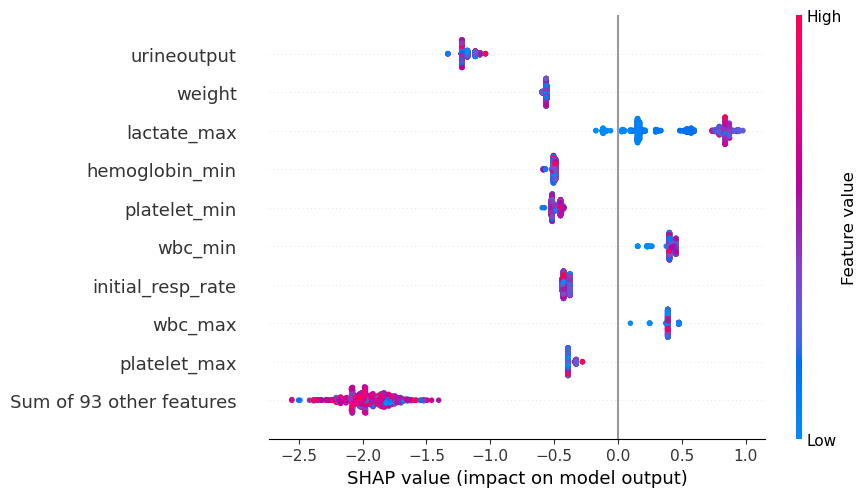

In [63]:
shap.plots.beeswarm(shap_values)

## Dependence plots

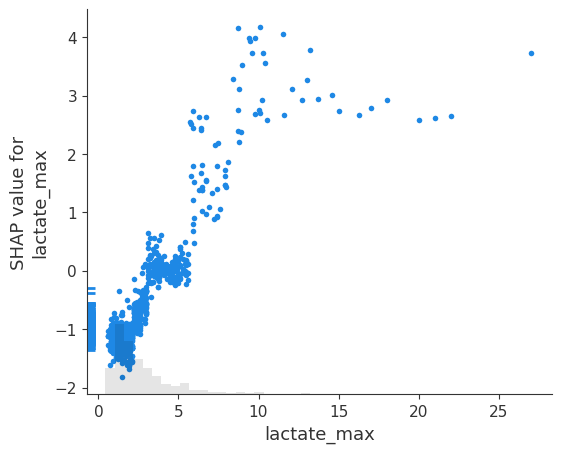

In [95]:
shap.plots.scatter(shap_values[:, 'lactate_max'])

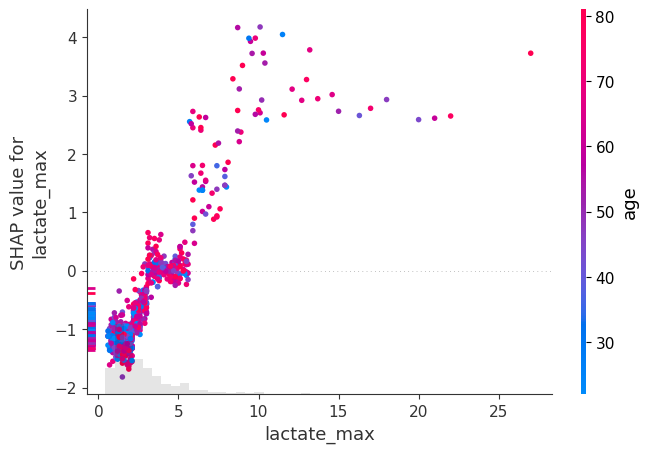

In [96]:
shap.plots.scatter(shap_values[:, 'lactate_max'], color=shap_values[:, 'age'])

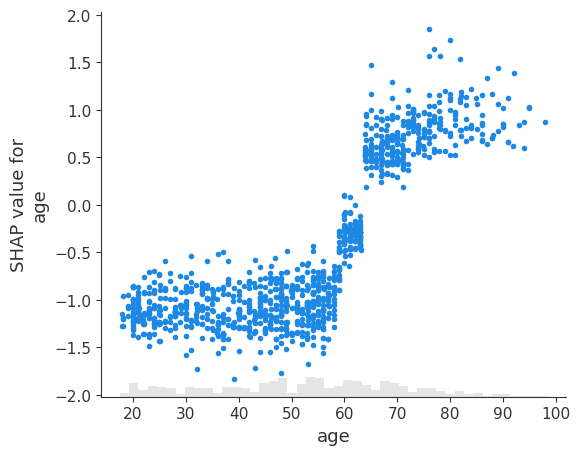

In [99]:
shap.plots.scatter(shap_values[:, 'age'])

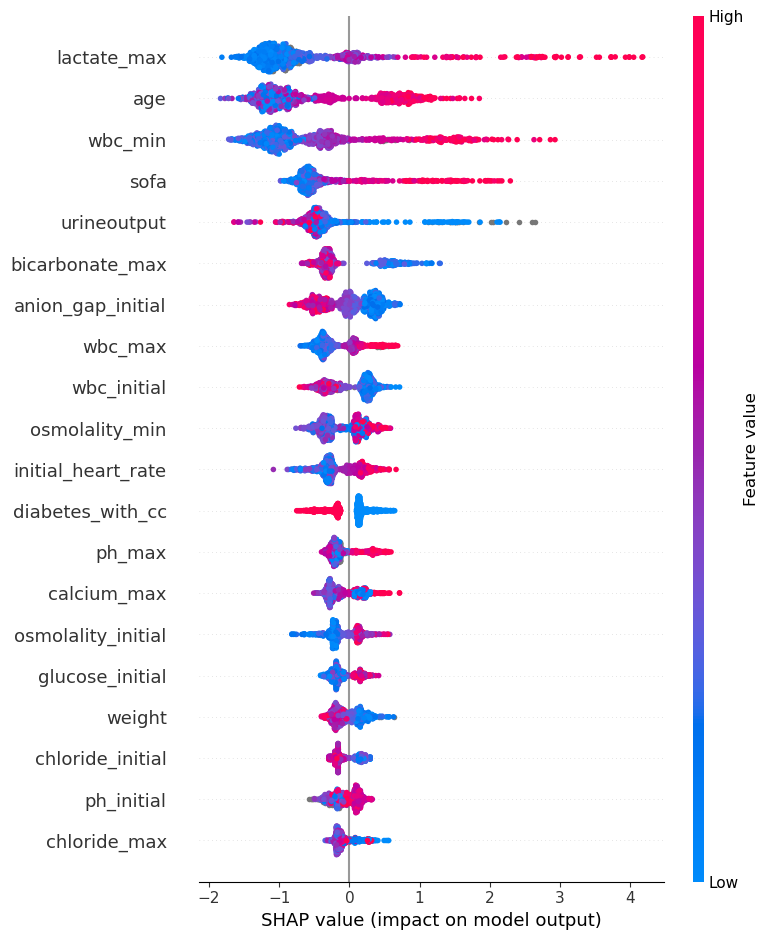

In [102]:
shap.summary_plot(shap_values, X_train)

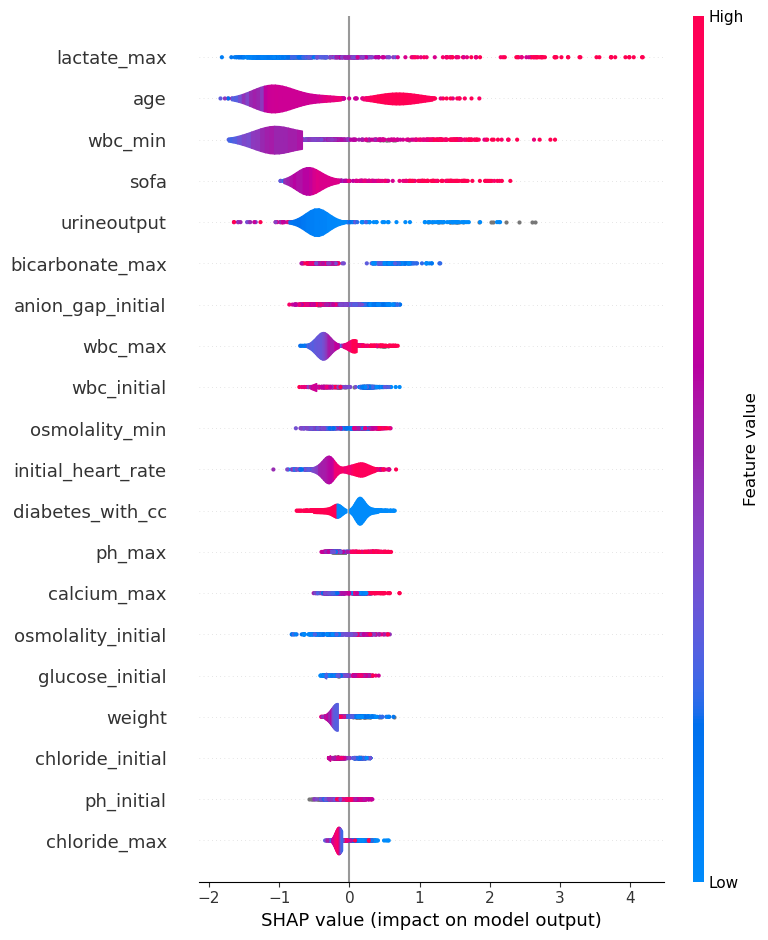

In [100]:
shap.summary_plot(shap_values, X_train, plot_type="violin", feature_names=X_train.columns)

Feature Interaction Detection with SHAP: Revealing Complex Dependencies Between Variables: https://medium.com/@lfoster49203/feature-interaction-detection-with-shap-revealing-complex-dependencies-between-variables-ecab7ff4dbc2

# LIME

In [69]:
!pip install lime 

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283839 sha256=3fe13253ce20b9577ad588a7d8bccb994d644aa8d5a2bb07390c4bc317faabad
  Stored in directory: /home/jovyan/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [76]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,  # Use normalized data for explanation
    feature_names=X_train.columns,
    mode='classification',
    class_names=['0', '1'],  # Adjust based on your target
    discretize_continuous=False,  # Disable discretization to test
    feature_selection='auto',
    random_state=42
)

# Select an instance to explain
instance_idx = 0  # Adjust to your desired instance
instance = X_train.iloc[instance_idx].values  # Use normalized instance

# Get LIME explanation
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=lambda x: model_xgb.predict_proba(X_train_normalized.iloc[x.index].values if isinstance(x, pd.Series) else x),  # Adjust predict_fn
    num_features=min(10, len(X_train.columns))
)

# Visualize the explanation
exp.show_in_notebook()  # For Jupyter notebook
exp.as_pyplot_figure()
plt.title(f"LIME Explanation for Instance {instance_idx}")
plt.tight_layout()
plt.show()

# Print data info
print("X_train shape:", X_train.shape)
print("X_train dtypes:\n", X_train.dtypes)
print("X_train sample:\n", X_train.head())

ValueError: Input contains NaN.